# Post-processing cloud cover

In [1]:
import xarray as xr
import os
import sys
import glob
import numpy as np
import time
from xclim import sdba
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import dask.distributed
from dask.distributed import Client
import tempfile
import dask

# Import datafinder
sys.path.append('/home/565/dh4185/mn51-dh4185/repos_collab/dataset_finder/')
from dataset_finder import *

# Import utils
sys.path.append('/home/565/dh4185/mn51-dh4185/repos_collab/nesp_bff/')
import utils

# Static metadata dictionaries
from utils import locations, model_dict, vars_1hr, vars_day, cmap_dict

# sys.path.append('/home/565/dh4185/mn51-dh4185/repos_collab/nesp_bff/xsdba')
# import xsdba

from sklearn.metrics import confusion_matrix, accuracy_score
from scipy.stats import entropy, wasserstein_distance, chisquare

# plotting niceties
sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (9, 5), "font.size": 12})


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/xclim/sdba.py:12: UserWarning: The `xclim.sdba` module has been split into its own package `xsdba`. Users are encouraged to use `xsdba` directly. For the time being, `xclim.sdba` will import `xsdba` to allow for API compatibility. This behaviour may change in the future. For more information, see: https://xsdba.readthedocs.io/en/stable/xclim_migration_guide.html
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


In [2]:
# Dask settings
dask.config.set({
    #'array.chunk-size': "256 MiB",
    #'array.slicing.split_large_chunks': True, 
    'distributed.comm.timeouts.connect': '120s',
    'distributed.comm.timeouts.tcp': '120s',
    'distributed.comm.retry.count': 10,
    'distributed.scheduler.allowed-failures': 20,
    "distributed.scheduler.worker-saturation": 1.1, #< This should use the new behaviour which helps with memory pile up
})

mem_lim = "63000mb" # 252000mb 63000mb
worker_n = 10
       
client = Client(n_workers=worker_n, threads_per_worker=1, local_directory = tempfile.mkdtemp(), memory_limit = mem_lim)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that i

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 10
Total threads: 10,Total memory: 586.73 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38821,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40659,Total threads: 1
Dashboard: /proxy/34157/status,Memory: 58.67 GiB
Nanny: tcp://127.0.0.1:34585,


In [3]:
##### Settings
_scenario = "historical" #"ssp370" ssp126 historical
_rcm = "BARRA-R2" #"BARPA-R" #CCAM-v2203-SN"
_gcm = "ERA5"
hist_slice = "1985-2014"
obs_name = "NatHERS" #"BARRAR2
_barra_v = "BARRA-R2" # C2
loc="Melbourne"

timezone_dict = {"Melbourne":"Melbourne", "Darwin":"Darwin", "Cairns":"Brisbane","Brisbane":"Brisbane",
                 "Longreach":"Brisbane","Mildura":"Melbourne","Adelaide":"Adelaide","Perth":"Perth",
                 "Sydney":"Sydney","Canberra":"Canberra","Hobart":"Hobart"}    
# Directories
root_dir = "/g/data/eg3/nesp_bff/"
plot_dir = "/g/data/eg3/nesp_bff/plots/qdc_adjustfactor/"

In [4]:
#< Functions
def fix_duplicate_times(ds):
    """Remove duplicate time entries, keeping the first occurrence."""
    if not ds.get_index("time").is_unique:
        print(f"Found {ds.get_index('time').duplicated().sum()} duplicate time entries.")
        ds = ds.sel(time=~ds.get_index("time").duplicated())
        print("Duplicates removed.")
    else:
        print("No duplicates found.")
    return ds

# Helper: assign to left bin edge (vectorized)
def assign_to_left_bin(x, bins):
    """
    Vectorized function used with xr.apply_ufunc.
    For each scalar x, returns the left-edge bin value where x belongs.
    Uses right=False so intervals are [left, right).
    """
    idx = np.digitize(x, bins, right=False) - 1   # 0-based bin index
    idx = np.clip(idx, 0, len(bins)-2)            # safety (ensure indices 0..8)
    return bins[idx]

def assign_to_bin_center(x, bins):
    """
    Assign each value x to the CENTER of the bin it falls into.
    """
    # Find 0-based bin index (same logic as before)
    idx = np.digitize(x, bins, right=False) - 1
    idx = np.clip(idx, 0, len(bins) - 2)
    centers = (bins[:-1] + bins[1:]) / 2.0
    return centers[idx]

def cloud_fraction_to_oktas_and_binned(da: xr.DataArray) -> xr.Dataset:
    """
    Convert cloud fraction in percent (0–100) to:
    1) Oktas (0–8)
    2) Binned cloud cover values mapped from oktas

    Output returned as an xarray.Dataset with matching dims/coords.
    """

    okta_map = np.array([0, 12.5, 25, 37.5, 50., 62.5, 75, 87.5, 100.])

    # Step 1 → convert to oktas
    oktas = xr.apply_ufunc(
        lambda x: np.rint(np.clip(x, 0, 100) / 100 * 8).astype(int),
        da,
        vectorize=True,
        dask="parallelized",
        output_dtypes=[int]
    )

    # Step 2 → convert to mapped midpoint values
    binned = xr.DataArray(
        okta_map[oktas],
        coords=da.coords,
        dims=da.dims,
        name="cloud_fraction_binned",
        attrs=dict(
            units="percent",
            description="Midpoint percent values for each okta bin"
        )
    )

    # Return dataset with both fields
    return xr.Dataset(
        data_vars=dict(
            oktas=oktas.assign_attrs(
                description="Cloud cover expressed in oktas (0–8)"
            ),
            binned=binned
        ),
        coords=da.coords,
        attrs=dict(
            source="Converted from cloud fraction percent using 8-bin okta scheme"
        )
    )

def plot_qdc_hourly_diagnostics_BARRA(da_obs_1hr,da_model_fut_1hr,
                                QDC_dict,adjusted,var,model,location, hour):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import matplotlib.gridspec as gridspec
    
    qdc = QDC_dict[hour]
    # adj = adjusted_slices[hour]
    adj = adjusted[adjusted.time.dt.hour==hour]
    
    obs_hour = da_obs_1hr.where(da_obs_1hr.time.dt.hour == hour, drop=True)
    fut_hour = da_model_fut_1hr.where(da_model_fut_1hr.time.dt.hour == hour, drop=True)
    
    # Set up GridSpec
    fig = plt.figure(figsize=(12, 8))
    gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2])
    
    ax0 = fig.add_subplot(gs[0, 0])  # Monthly means
    ax1 = fig.add_subplot(gs[0, 1])  # Heatmap
    ax2 = fig.add_subplot(gs[1, :])  # Full-width histogram
    
    fig.suptitle(f"{location}: QDC Diagnostics for {model} {var} - Hour {hour:02d} UTC", fontsize=14, y=0.95)
    
    # 1a. Monthly means
    obs_hour.groupby("time.month").mean().plot(ax=ax0, label="BARRA-R2", color="blue")
    fut_hour.groupby("time.month").mean().plot(ax=ax0, label="NatHERS", color="red")
    adj.groupby("time.month").mean().plot(ax=ax0, label="BARRA-R2 adjusted", linestyle="--", color="purple")
    ax0.set_title("Monthly Mean by Hour")
    ax0.legend()
    
    # 1b. Adjustment factor heatmap
    af = qdc.ds.af
    vmin, vmax = float(af.min()), float(af.max())
    if vmin < 0 and vmax > 0:
        cmap = "RdBu_r"
        center = 0.0
    else:
        cmap = "viridis"
        center = None
    
    af.transpose("month", "quantiles").plot.pcolormesh(
            ax=ax1, cmap=cmap, center=center,
            x="quantiles", y="month",
            cbar_kwargs={"label": "Adjustment Factor"}
    )
    ax1.set_title("QDC Adjustment Factors")
    
    # 2. Histogram
    sns.histplot(obs_hour.values.flatten(), ax=ax2, label="BARRA-R2", kde=True, stat="density", bins=50, color="blue")
    sns.histplot(fut_hour.values.flatten(), ax=ax2, label="NatHERS", kde=True, stat="density", bins=50, color="red")
    sns.histplot(adj.values.flatten(), ax=ax2, label="BARRA-R2 adjusted", kde=True, stat="density", bins=50, color="purple")
    ax2.set_title("Distributions")
    ax2.legend()

In [5]:
locations[loc]

{'Lat': -37.67, 'Lon': 144.83, 'Elev': 118.8}

In [6]:
ds_barra = xr.open_dataset(f"{root_dir}step1_raw_data_extraction/{_barra_v}/{loc}_AUS-11_ERA5_historical_hres_BOM_{_barra_v}_v1_1hr_1985-2014.nc").sel(time=slice("1990","2014")).load()
ds_nathers = xr.open_dataset(glob.glob(f"{root_dir}/NatHERS/raw_data/{loc}_*_NatHERS_1990-2015.nc")[0]).load()

In [11]:
%%time
barrac2_all_1hr = get_datasets("ACS_DS",
                        rcm = "BARRA-C2",
                        scenario = "historical",
                        timescale = "1hr",
                        year = year_range(1990, 2014))

barrac2_select_1hr = barrac2_all_1hr.select(var = ["clt"], exact_match=True)
barrac2_select_1hr

CPU times: user 26.3 s, sys: 2.16 s, total: 28.4 s
Wall time: 27.5 s


,grid,org,gcm,scenario,mdl_run,rcm,ver,timescale,,var,date_created,year,month
0,AUST-04,BOM,ERA5,historical,hres,BARRA-C2,v1,1hr,,clt,"latest, v20250528",1990 to 2014,1 to 12


In [12]:
ds_barrac2 = xr.open_mfdataset(barrac2_select_1hr.get_files(), parallel=True,
                    preprocess=lambda ds: utils.preprocess_location(ds, 
                                                                    locations[loc]['Lat'],
                                                                    locations[loc]['Lon'])).load()
ds_barrac2

INFO: Clash on date_created: Chose "latest" over "v20250528" for var = clt; year = 1990 to 2014; month = 1 to 12


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/xclim/sdba.py:12: UserWarning: The `xclim.sdba` module has been split into its own package `xsdba`. Users are encouraged to use `xsdba` directly. For the time being, `xclim.sdba` will import `xsdba` to allow for API compatibility. This behaviour may change in the future. For more information, see: https://xsdba.readthedocs.io/en/stable/xclim_migration_guide.html
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/xclim/sdba.py:12: UserWarning: The `xclim.sdba` module has been split into its own package `xsdba`. Users are encouraged to use `xsdba` directly. For the time being, `xclim.sdba` will import `xsdba` to allow for API compatibility. This behaviour may change in the future. For more information, see: https://xsdba.readthedocs.io/en/stable/xclim_migration_guide.html
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 219144)
Coordinates:
  * time     (time) datetime64[ns] 2MB 1990-01-01T00:30:00 ... 2014-12-31T23:...
    lat      float64 8B -37.69
    lon      float64 8B 144.8
    crs      int32 4B 0
Data variables:
    clt      (time) float64 2MB 30.5 1.938 0.0 0.0 ... 100.0 100.0 100.0 100.0
Attributes: (12/60)
    axiom_version:             0.1.0
    axiom_schemas_version:     0.1.0
    axiom_schema:              cordex-1H.json
    productive_version:        500df2a
    variable_version:          v20241004
    Conventions:               CF-1.10, ACDD-1.3
    ...                        ...
    date_modified:             2024-10-11T00:33:57Z
    date_metadata_modified:    2024-10-11T00:33:57Z
    history:                   Thu Jun 06 06:49:02 2024: /g/data/access/ngm/m...
    references:                https://doi.org/10.25914/1x6g-2v48
    license:                   https://doi.org/10.25914/1x6g-2v48
    acknowledgement:           The production of BARRA2 was supported with fu...

In [30]:
# Convert to local time
barra_time_utc = pd.to_datetime(ds_barra.time.values).tz_localize('UTC')
barra_time_utc_to_local = barra_time_utc.tz_convert(f'Australia/{timezone_dict[loc]}').tz_localize(None)
ds_barra_local = ds_barra.copy()
ds_barra_local = ds_barra_local.assign_coords(time=barra_time_utc_to_local)

ds_barrac2_local = ds_barrac2.copy()
ds_barrac2_local = ds_barrac2_local.assign_coords(time=barra_time_utc_to_local)

offset = pd.to_timedelta(ds_nathers.coords["time_offset"].item(), unit="h")
ds_nathers_local = ds_nathers.copy()
ds_nathers_local = ds_nathers.assign_coords(time=ds_nathers["time"] + offset)
# ds_nathers_local.coords["time_offset"] = 0

# Apply  duplicate time check to both datasets
ds_barra_local = fix_duplicate_times(ds_barra_local)
ds_nathers_local = fix_duplicate_times(ds_nathers_local)
ds_barrac2_local = fix_duplicate_times(ds_barrac2_local)

ds_nathers_local["lat"] = ds_barra_local["lat"]
ds_nathers_local["lon"] = ds_barra_local["lon"]
ds_barra_local, ds_nathers_local = xr.align(ds_barra_local, ds_nathers_local, join="inner")
ds_barrac2_local, ds_nathers_local = xr.align(ds_barrac2_local, ds_nathers_local, join="inner")

da_barra = ds_barra_local["clt"].copy()
da_nathers = ds_nathers_local["clt"].copy()
da_barrac2 = ds_barrac2_local["clt"].copy()

Found 25 duplicate time entries.
Duplicates removed.
No duplicates found.
Found 25 duplicate time entries.
Duplicates removed.


Text(0.5, 1.0, 'Cloud cover diurnal cycle (1990-2014) for Melbourne')

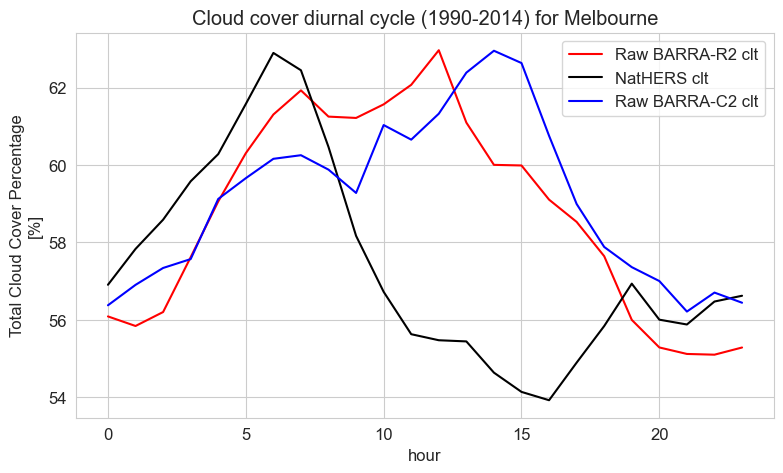

In [31]:
da_barra.groupby("time.hour").mean().plot(label = "Raw BARRA-R2 clt", color='red')
da_nathers.groupby("time.hour").mean().plot(label = "NatHERS clt", color ='black') # orange
da_barrac2.groupby("time.hour").mean().plot(label = "Raw BARRA-C2 clt", color ='blue') # blue
plt.legend()
plt.title(f"Cloud cover diurnal cycle (1990-2014) for {loc}")

In [32]:
# count spurious values outside 0..100
n_nathers_below = (da_nathers < 0).sum().item()
n_nathers_above = (da_nathers > 100).sum().item()
n_barra_below = (da_barra < 0).sum().item()
n_barra_above = (da_barra > 100).sum().item()

n_barrac2_below = (da_barrac2 < 0).sum().item()
n_barrac2_above = (da_barrac2 > 100).sum().item()

print(f"NatHERS: {n_nathers_below} values <0, {n_nathers_above} values >100")
print(f"BARRA-R2 : {n_barra_below} values <0, {n_barra_above} values >100")
print(f"BARRA-C2 : {n_barrac2_below} values <0, {n_barrac2_above} values >100")

# clip values to [0, 100]
nathers = da_nathers.clip(min=0, max=100)
barra = da_barra.clip(min=0, max=100)
barrac2 = da_barrac2.clip(min=0, max=100)

# align timestamps (inner join) so both arrays share same time index
nathers, barra = xr.align(nathers, barra, join="inner")
nathers, barrac2 = xr.align(nathers, barrac2, join="inner")
print("Aligned lengths:", nathers.sizes["time"])


NatHERS: 0 values <0, 0 values >100
BARRA-R2 : 0 values <0, 0 values >100
BARRA-C2 : 0 values <0, 0 values >100
Aligned lengths: 219119


In [33]:
# Bin edges: left edges are 0, 12.5, 25, ... , 100, and include a final edge 112.5 to capture 100.
bins = np.array([0, 12.5, 25, 37.5, 50., 62.5, 75, 87.5, 100., 112.5])


barra_binned = cloud_fraction_to_oktas_and_binned(barra)
nathers_binned = cloud_fraction_to_oktas_and_binned(nathers)
barrac2_binned = cloud_fraction_to_oktas_and_binned(barrac2)

# Quick sanity output: unique values (should be left-edge set)
print("Unique NatHERS binned values:", np.unique(nathers_binned.binned.values))
print("Unique BARRA-R2 binned values:", np.unique(barra_binned.binned.values))
print("Unique BARRA-C2 binned values:", np.unique(barrac2_binned.binned.values))

Unique NatHERS binned values: [  0.   12.5  25.   37.5  50.   62.5  75.   87.5 100. ]
Unique BARRA-R2 binned values: [  0.   12.5  25.   37.5  50.   62.5  75.   87.5 100. ]
Unique BARRA-C2 binned values: [  0.   12.5  25.   37.5  50.   62.5  75.   87.5 100. ]


Text(0.5, 1.0, 'Binned cloud cover diurnal cycle (1990-2014) for Melbourne')

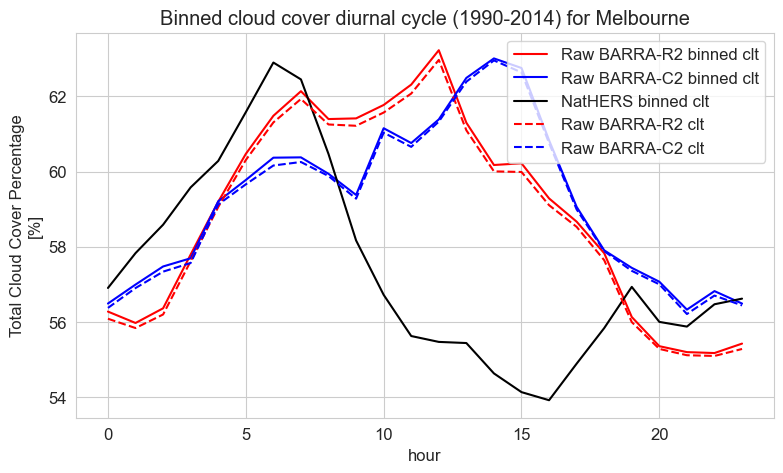

In [34]:
barra_binned.binned.groupby("time.hour").mean().plot(label = "Raw BARRA-R2 binned clt", color='red') 
barrac2_binned.binned.groupby("time.hour").mean().plot(label = "Raw BARRA-C2 binned clt", color='blue')
nathers_binned.binned.groupby("time.hour").mean().plot(label = "NatHERS binned clt", color='black') 
da_barra.groupby("time.hour").mean().plot(label = "Raw BARRA-R2 clt", color='red', ls='--')
da_barrac2.groupby("time.hour").mean().plot(label = "Raw BARRA-C2 clt", color='blue', ls='--') 

plt.legend()
plt.title(f"Binned cloud cover diurnal cycle (1990-2014) for {loc}")

In [35]:
# Build conditional PMFs with a sliding window
def build_conditional_pmf_sliding(obs_idx, mod_idx, window=1):
    """
    For each hour (0..23), pool data from hours in [h-window, ..., h+window]
    and compute empirical PMFs P(obs_bin | mod_bin) for mod_bin in 0..8.
    Returns dict keyed by (mod_bin, hour) -> pmf (length 9).
    """
    cond_pmf = {}
    hours = np.arange(24)

    # time hour arrays for selection
    obs_hours = obs_idx['time'].dt.hour
    mod_hours = mod_idx['time'].dt.hour

    for hour in hours:
        hours_to_use = [(hour + offset) % 24 for offset in range(-window, window + 1)]

        # subset arrays to those hours (pooling)
        obs_slice = obs_idx.where(obs_hours.isin(hours_to_use), drop=True)
        mod_slice = mod_idx.where(mod_hours.isin(hours_to_use), drop=True)

        # flatten
        obs_vals = obs_slice.values.ravel()
        mod_vals = mod_slice.values.ravel()

        # filter valid pairs
        mask = ~np.isnan(obs_vals) & ~np.isnan(mod_vals)
        obs_vals = obs_vals[mask].astype(int)
        mod_vals = mod_vals[mask].astype(int)

        # build conditional PMFs for each mod_bin (0..8)
        for m_bin in range(len(bins)-1):
            obs_given_mod = obs_vals[mod_vals == m_bin]
            if obs_given_mod.size == 0:
                pmf = np.zeros(len(bins)-1)
            else:
                counts = np.bincount(obs_given_mod, minlength=(len(bins)-1))
                pmf = counts / counts.sum()
            cond_pmf[(m_bin, hour)] = pmf

    return cond_pmf

# Build PMFs with a chosen window (try window=1 first)
window = 3
cond_pmf = build_conditional_pmf_sliding(nathers_binned.oktas, barra_binned.oktas, window=window)
cond_pmf_c2 = build_conditional_pmf_sliding(nathers_binned.oktas, barrac2_binned.oktas, window=window)

print("PMFs built for combinations (R2):", len(cond_pmf))
print("PMFs built for combinations (C2):", len(cond_pmf_c2))

# inspect an example
print("Example PMF for R2 (mod_bin=4, hour=12):", cond_pmf.get((4,12)))
print("Example PMF for C2 (mod_bin=4, hour=12):", cond_pmf_c2.get((4,12)))

PMFs built for combinations (R2): 216
PMFs built for combinations (C2): 216
Example PMF for R2 (mod_bin=4, hour=12): [0.03500834 0.12979281 0.07954275 0.12264825 0.09097404 0.18456775
 0.15027387 0.16908788 0.03810431]
Example PMF for C2 (mod_bin=4, hour=12): [0.01569101 0.12432106 0.0920338  0.13548582 0.10319855 0.18708509
 0.14846107 0.16143633 0.03228727]


In [36]:
# Stochastic mapping using averaged window PMFs

def map_mod_to_obs_stochastic_sliding(mod_idx_da, cond_pmf, bins, seed=None, window=1):
    """
    For each model time step, find model bin m and hour h.
    Gather PMFs (m, h') for h' in h±window and average them (if present).
    Sample an obs_bin from the averaged PMF and return left-edge percent.
    """
    rng = np.random.default_rng(seed)
    mod_vals = mod_idx_da.values
    times = pd.DatetimeIndex(mod_idx_da['time'].values)
    mapped_idx = np.full(mod_vals.shape, np.nan)

    for i, (mval, t) in enumerate(zip(mod_vals, times)):
        if np.isnan(mval):
            continue
        mbin = int(mval)
        hour = t.hour
        hours_to_use = [(hour + o) % 24 for o in range(-window, window+1)]

        # collect PMFs for this mbin across the window hours (if they exist)
        pmf_list = []
        for h in hours_to_use:
            pmf = cond_pmf.get((mbin, h))
            if pmf is not None:
                pmf_list.append(pmf)
        if len(pmf_list) == 0:
            mapped_idx[i] = mbin
            continue

        avg_pmf = np.mean(pmf_list, axis=0)
        # normalize (safety)
        if avg_pmf.sum() == 0:
            mapped_idx[i] = mbin
            continue
        avg_pmf = avg_pmf / avg_pmf.sum()
        sampled = rng.choice(np.arange(len(bins)-1), p=avg_pmf)
        mapped_idx[i] = sampled

    # convert bin indices back to left-edge percent values
    mapped_left = bins[mapped_idx.astype(int)]
    return xr.DataArray(mapped_left, coords=mod_idx_da.coords, dims=mod_idx_da.dims, name="clt_adj")

# Run mapping with chosen window and seed
seed = 42
mod_adj = map_mod_to_obs_stochastic_sliding(barra_binned.oktas, cond_pmf, bins, seed=seed, window=window)
mod_adj_binned = cloud_fraction_to_oktas_and_binned(mod_adj)
mod_adj_binned

mod_adj_c2 = map_mod_to_obs_stochastic_sliding(barrac2_binned.oktas, cond_pmf_c2, bins, seed=seed, window=window)
mod_adj_c2_binned = cloud_fraction_to_oktas_and_binned(mod_adj_c2)
mod_adj_c2_binned

# quick peek
print("First 10 adjusted values (R2):", mod_adj_binned.binned.values[:10])
print("First 10 adjusted values (C2):", mod_adj_binned.binned.values[:10])

First 10 adjusted values (R2): [87.5 25.  50.  25.   0.  87.5 37.5 50.  12.5 25. ]
First 10 adjusted values (C2): [87.5 25.  50.  25.   0.  87.5 37.5 50.  12.5 25. ]


=== Distribution Metrics ===
KL divergence (raw) (R2): 0.3905, (adj): 0.0000
Wasserstein distance (raw) (R2): 0.7427, (adj): 0.0068
Chi-square statistic (raw) (R2): 469266.4, (adj): 7.5
KL divergence (raw) (C2): 0.5493, (adj): 0.0000
Wasserstein distance (raw) (C2): 0.9341, (adj): 0.0039
Chi-square statistic (raw) (C2): 708733.5, (adj): 2.6


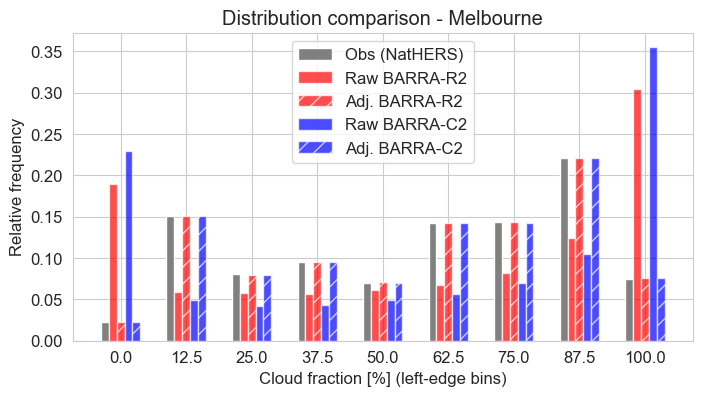

In [37]:
# distribution metrics and plot
mod_codes = barra_binned.oktas
modc2_codes = barrac2_binned.oktas
obs_codes = nathers_binned.oktas
adj_codes = mod_adj_binned.oktas
adjc2_codes = mod_adj_c2_binned.oktas

# frequencies (ensure all bins present using reindex)
obs_freq = pd.Series(obs_codes).value_counts(normalize=True).sort_index().reindex(range(len(bins)-1), fill_value=0)
mod_freq = pd.Series(mod_codes).value_counts(normalize=True).sort_index().reindex(range(len(bins)-1), fill_value=0)
adj_freq = pd.Series(adj_codes).value_counts(normalize=True).sort_index().reindex(range(len(bins)-1), fill_value=0)
modc2_freq = pd.Series(modc2_codes).value_counts(normalize=True).sort_index().reindex(range(len(bins)-1), fill_value=0)
adjc2_freq = pd.Series(adjc2_codes).value_counts(normalize=True).sort_index().reindex(range(len(bins)-1), fill_value=0)

# KL divergence (obs vs model/adj)
kl_raw = entropy(obs_freq + 1e-12, mod_freq + 1e-12)  # tiny epsilon for safety
kl_adj = entropy(obs_freq + 1e-12, adj_freq + 1e-12)
kl_raw_c2 = entropy(obs_freq + 1e-12, modc2_freq + 1e-12)  # tiny epsilon for safety
kl_adj_c2 = entropy(obs_freq + 1e-12, adjc2_freq + 1e-12)

# Wasserstein distance (treating codes as ordered support)
wd_raw = wasserstein_distance(obs_codes, mod_codes)
wd_adj = wasserstein_distance(obs_codes, adj_codes)
wd_raw_c2 = wasserstein_distance(obs_codes, modc2_codes)
wd_adj_c2 = wasserstein_distance(obs_codes, adjc2_codes)

# Chi-square (use counts not normalized)
counts_obs = pd.Series(obs_codes).value_counts().sort_index().reindex(range(len(bins)-1), fill_value=0)
counts_mod = pd.Series(mod_codes).value_counts().sort_index().reindex(range(len(bins)-1), fill_value=0)
counts_adj = pd.Series(adj_codes).value_counts().sort_index().reindex(range(len(bins)-1), fill_value=0)
counts_mod_c2 = pd.Series(modc2_codes).value_counts().sort_index().reindex(range(len(bins)-1), fill_value=0)
counts_adj_c2 = pd.Series(adjc2_codes).value_counts().sort_index().reindex(range(len(bins)-1), fill_value=0)

chi2_raw = chisquare(f_obs=counts_mod.values, f_exp=counts_obs.values)
chi2_adj = chisquare(f_obs=counts_adj.values, f_exp=counts_obs.values)
chi2_raw_c2 = chisquare(f_obs=counts_mod_c2.values, f_exp=counts_obs.values)
chi2_adj_c2 = chisquare(f_obs=counts_adj_c2.values, f_exp=counts_obs.values)

print("=== Distribution Metrics ===")
print(f"KL divergence (raw) (R2): {kl_raw:.4f}, (adj): {kl_adj:.4f}")
print(f"Wasserstein distance (raw) (R2): {wd_raw:.4f}, (adj): {wd_adj:.4f}")
print(f"Chi-square statistic (raw) (R2): {chi2_raw.statistic:.1f}, (adj): {chi2_adj.statistic:.1f}")

print(f"KL divergence (raw) (C2): {kl_raw_c2:.4f}, (adj): {kl_adj_c2:.4f}")
print(f"Wasserstein distance (raw) (C2): {wd_raw_c2:.4f}, (adj): {wd_adj_c2:.4f}")
print(f"Chi-square statistic (raw) (C2): {chi2_raw_c2.statistic:.1f}, (adj): {chi2_adj_c2.statistic:.1f}")

# Plot
x = bins[:-1]   # left-edge percent values for x-axis
width = 1.5
plt.figure(figsize=(8,4))
plt.bar(x - 2*width, obs_freq.values, width=width, label="Obs (NatHERS)", align="center", color="gray")
plt.bar(x - width, mod_freq.values, width=width, label="Raw BARRA-R2", align="center", color = "red", alpha=0.7)
plt.bar(x, adj_freq.values, width=width, label="Adj. BARRA-R2", align="center", color = "red", hatch="//", alpha=0.7)
plt.bar(x + width, modc2_freq.values, width=width, label="Raw BARRA-C2", align="center", color = "blue", alpha=0.7)
plt.bar(x + 2*width, adjc2_freq.values, width=width, label="Adj. BARRA-C2", align="center", color = "blue", hatch="//",alpha=0.7)

plt.xticks(x)
plt.xlabel("Cloud fraction [%] (left-edge bins)")
plt.ylabel("Relative frequency")
plt.title(f"Distribution comparison - {loc}")
plt.legend()
plt.show()


Accuracy (raw R2): 0.149
Accuracy (adj R2): 0.178
Accuracy (raw C2): 0.143
Accuracy (adj C2): 0.183


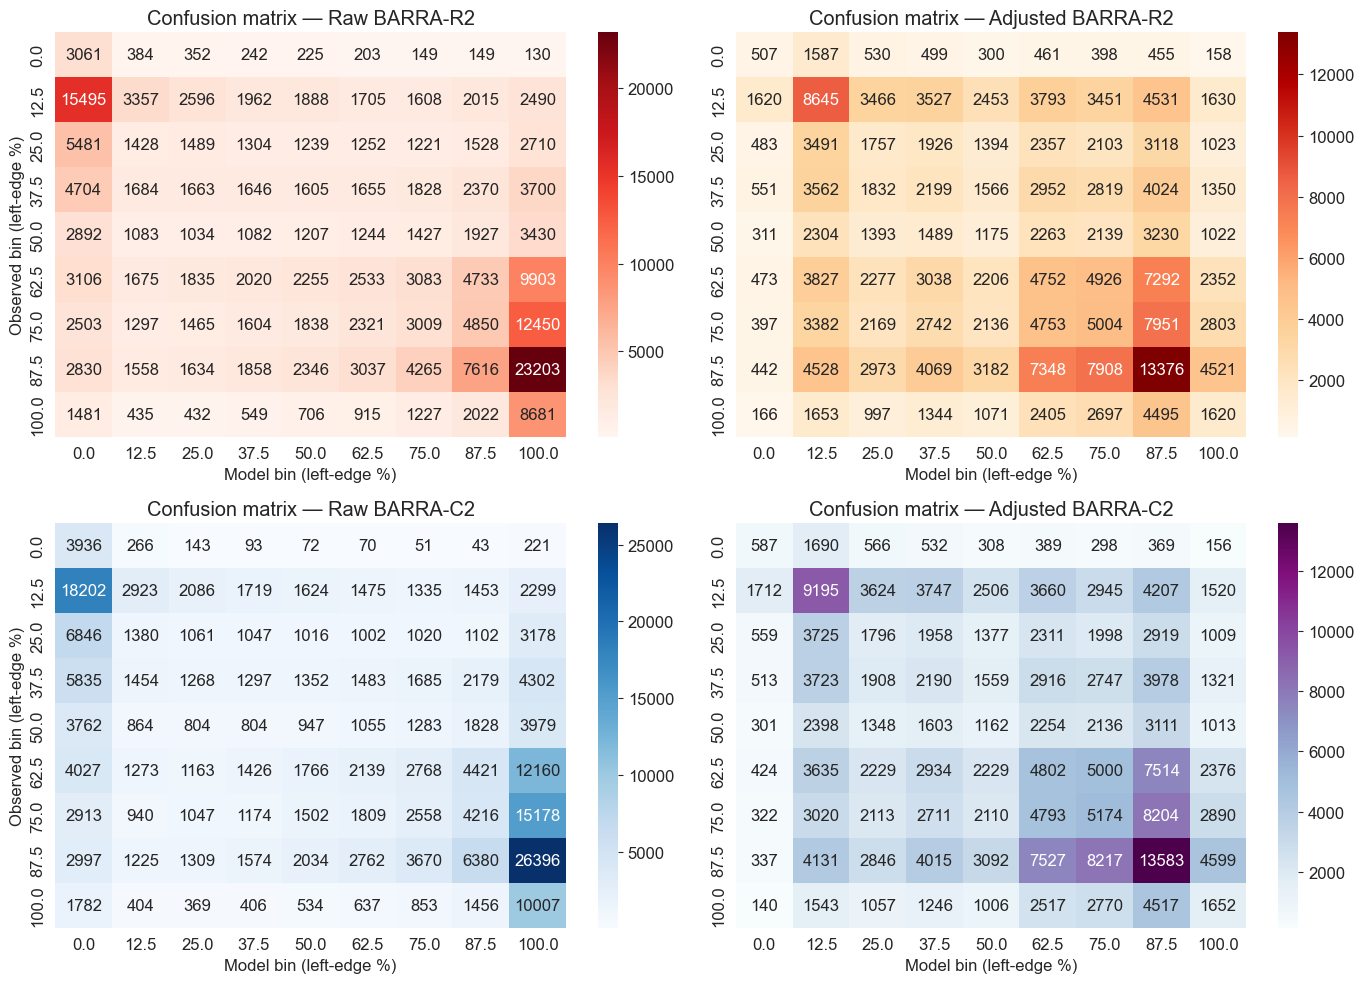

CPU times: user 3.16 s, sys: 474 ms, total: 3.63 s
Wall time: 3.26 s


In [40]:
%%time
# Confusion matrices & accuracy

labels = list(range(len(bins)-1))  # 0..8

cm_raw = confusion_matrix(obs_codes, mod_codes, labels=labels)
cm_adj = confusion_matrix(obs_codes, adj_codes, labels=labels)
cm_rawc2 = confusion_matrix(obs_codes, modc2_codes, labels=labels)
cm_adjc2 = confusion_matrix(obs_codes, adjc2_codes, labels=labels)

acc_raw = accuracy_score(obs_codes, mod_codes)
acc_adj = accuracy_score(obs_codes, adj_codes)
acc_rawc2 = accuracy_score(obs_codes, modc2_codes)
acc_adjc2 = accuracy_score(obs_codes, adjc2_codes)

print(f"Accuracy (raw R2): {acc_raw:.3f}")
print(f"Accuracy (adj R2): {acc_adj:.3f}")
print(f"Accuracy (raw C2): {acc_rawc2:.3f}")
print(f"Accuracy (adj C2): {acc_adjc2:.3f}")

# Plot confusion matrices
fig, axs = plt.subplots(2, 2, figsize=(14,10))
axs = axs.flatten()

sns.heatmap(cm_raw, annot=True, fmt='d', ax=axs[0], cmap='Reds', xticklabels=bins[:-1], yticklabels=bins[:-1])
axs[0].set_title("Confusion matrix — Raw BARRA-R2")
axs[0].set_xlabel("Model bin (left-edge %)")
axs[0].set_ylabel("Observed bin (left-edge %)")
sns.heatmap(cm_adj, annot=True, fmt='d', ax=axs[1], cmap='OrRd', xticklabels=bins[:-1], yticklabels=bins[:-1])
axs[1].set_title("Confusion matrix — Adjusted BARRA-R2")
axs[1].set_xlabel("Model bin (left-edge %)")
sns.heatmap(cm_rawc2, annot=True, fmt='d', ax=axs[2], cmap='Blues', xticklabels=bins[:-1], yticklabels=bins[:-1])
axs[2].set_title("Confusion matrix — Raw BARRA-C2")
axs[2].set_xlabel("Model bin (left-edge %)")
axs[2].set_ylabel("Observed bin (left-edge %)")
sns.heatmap(cm_adjc2, annot=True, fmt='d', ax=axs[3], cmap='BuPu', xticklabels=bins[:-1], yticklabels=bins[:-1])
axs[3].set_title("Confusion matrix — Adjusted BARRA-C2")
axs[3].set_xlabel("Model bin (left-edge %)")
plt.tight_layout()
plt.show()


Mean persistence (obs/raw R2/adj R2/raw C2/adj C2): 0.5086 0.3685 0.1414 0.3218 0.146


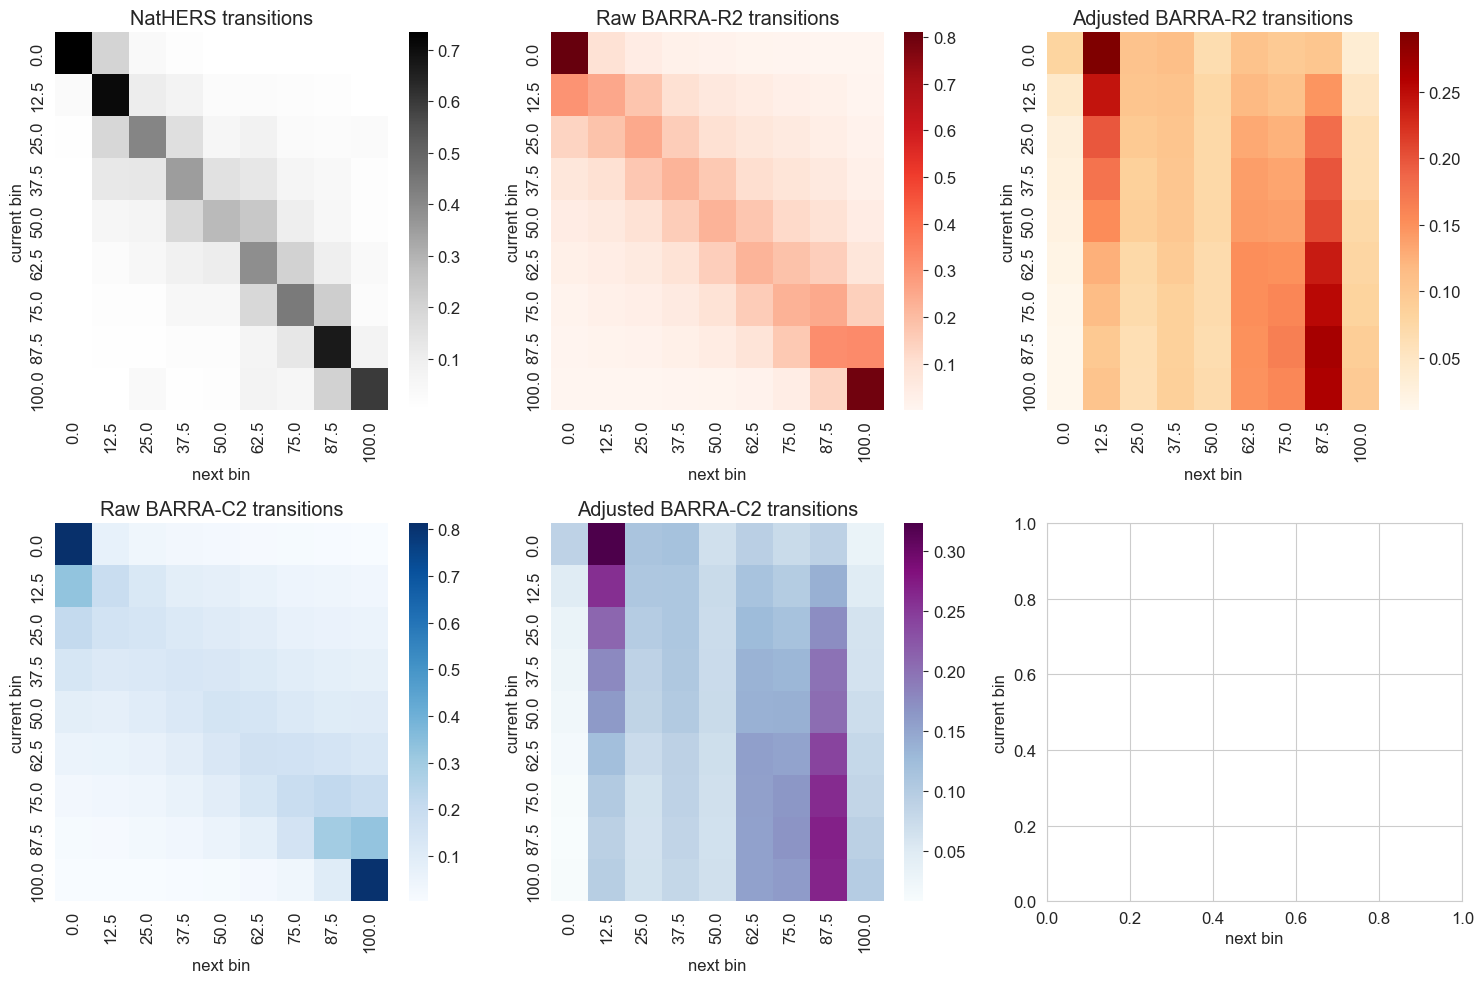

CPU times: user 10min 46s, sys: 7.7 s, total: 10min 54s
Wall time: 10min 48s


In [42]:
%%time
# Transitions

def transition_matrix(codes, n_classes):
    """Return row-normalized transition matrix P(next | current)."""
    mat = np.zeros((n_classes, n_classes))
    for a, b in zip(codes[:-1], codes[1:]):
        mat[a, b] += 1
    # avoid division by zero: normalize rows when row sum > 0
    row_sums = mat.sum(axis=1, keepdims=True)
    with np.errstate(invalid='ignore', divide='ignore'):
        mat_norm = np.divide(mat, row_sums, where=(row_sums!=0))
    mat_norm = np.nan_to_num(mat_norm)
    return mat_norm

n_classes = len(bins)-1
tm_obs = transition_matrix(obs_codes, n_classes)
tm_raw = transition_matrix(mod_codes, n_classes)
tm_adj = transition_matrix(adj_codes, n_classes)
tm_raw_c2 = transition_matrix(modc2_codes, n_classes)
tm_adj_c2 = transition_matrix(adjc2_codes, n_classes)

persistence_obs = np.mean(np.diag(tm_obs))
persistence_raw = np.mean(np.diag(tm_raw))
persistence_adj = np.mean(np.diag(tm_adj))
persistence_raw_c2 = np.mean(np.diag(tm_raw_c2))
persistence_adj_c2 = np.mean(np.diag(tm_adj_c2))

print("Mean persistence (obs/raw R2/adj R2/raw C2/adj C2):", np.round(persistence_obs,4), 
      np.round(persistence_raw,4), np.round(persistence_adj,4), np.round(persistence_raw_c2,4),
               np.round(persistence_adj_c2,4))

# Plot matrices
fig, axs = plt.subplots(2,3, figsize=(15,10))
axs = axs.flatten()

sns.heatmap(tm_obs, ax=axs[0], cmap='Greys', xticklabels=bins[:-1], yticklabels=bins[:-1])
axs[0].set_title("NatHERS transitions")
sns.heatmap(tm_raw, ax=axs[1], cmap='Reds', xticklabels=bins[:-1], yticklabels=bins[:-1])
axs[1].set_title("Raw BARRA-R2 transitions")
sns.heatmap(tm_adj, ax=axs[2], cmap='OrRd', xticklabels=bins[:-1], yticklabels=bins[:-1])
axs[2].set_title("Adjusted BARRA-R2 transitions")
sns.heatmap(tm_raw_c2, ax=axs[3], cmap='Blues', xticklabels=bins[:-1], yticklabels=bins[:-1])
axs[3].set_title("Raw BARRA-C2 transitions")
sns.heatmap(tm_adj_c2, ax=axs[4], cmap='BuPu', xticklabels=bins[:-1], yticklabels=bins[:-1])
axs[4].set_title("Adjusted BARRA-C2 transitions")
      
for ax in axs:
    ax.set_xlabel("next bin")
    ax.set_ylabel("current bin")
plt.tight_layout()
plt.show()


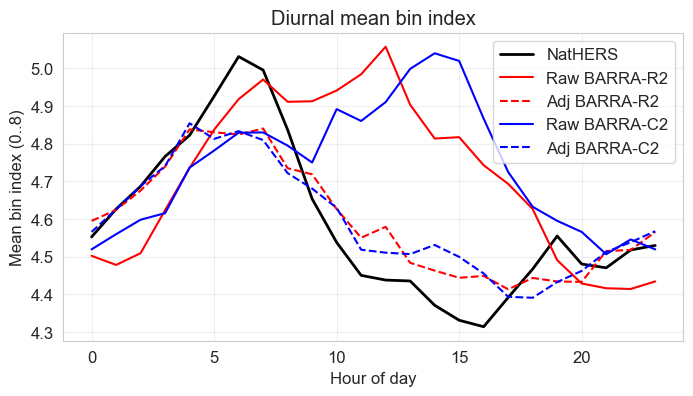

Hourly mean correlation (R2): raw=0.203, adj=0.923
Hourly mean correlation (C2): raw=-0.122, adj=0.906


In [45]:
# Diurnal profiles
obs_hourly = obs_codes.groupby("time.hour").mean()
mod_hourly = mod_codes.groupby("time.hour").mean()
adj_hourly = adj_codes.groupby("time.hour").mean()
modc2_hourly = modc2_codes.groupby("time.hour").mean()
adjc2_hourly = adjc2_codes.groupby("time.hour").mean()

plt.figure(figsize=(8,4))
plt.plot(obs_hourly, label="NatHERS", lw=2, color="black")
plt.plot(mod_hourly, label="Raw BARRA-R2", lw=1.5, color="red")
plt.plot(adj_hourly, label="Adj BARRA-R2", lw=1.5, color="red",ls="--")
plt.plot(modc2_hourly, label="Raw BARRA-C2", lw=1.5, color="blue")
plt.plot(adjc2_hourly, label="Adj BARRA-C2", lw=1.5, color="blue",ls="--")

plt.xlabel("Hour of day")
plt.ylabel("Mean bin index (0..8)")
plt.title(f"Binned cloud cover diurnal cycle (1990-2014) for {loc}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Hourly correlation with observations
corr_raw = np.corrcoef(obs_hourly.values, mod_hourly.values)[0,1]
corr_adj = np.corrcoef(obs_hourly.values, adj_hourly.values)[0,1]
corr_raw_c2 = np.corrcoef(obs_hourly.values, modc2_hourly.values)[0,1]
corr_adj_c2 = np.corrcoef(obs_hourly.values, adjc2_hourly.values)[0,1]
print(f"Hourly mean correlation (R2): raw={corr_raw:.3f}, adj={corr_adj:.3f}")
print(f"Hourly mean correlation (C2): raw={corr_raw_c2:.3f}, adj={corr_adj_c2:.3f}")


Text(0.5, 1.0, 'Binned cloud cover fraction diurnal cycle (1990-2014) for Melbourne')

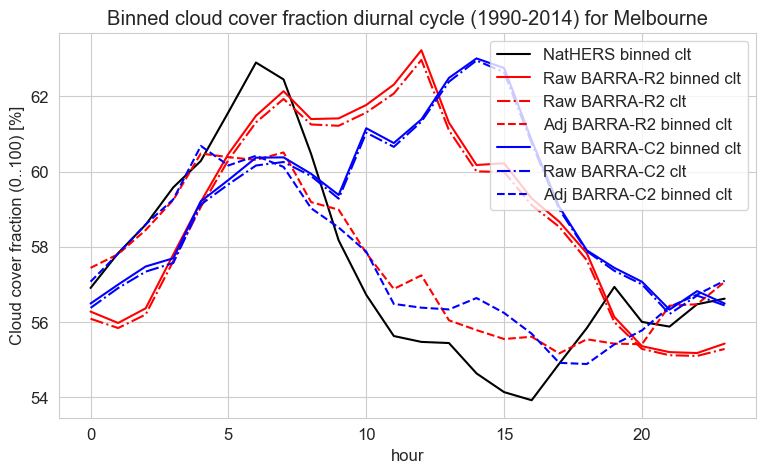

In [50]:
nathers_binned.binned.groupby("time.hour").mean().plot(label = "NatHERS binned clt", color="black") 
barra_binned.binned.groupby("time.hour").mean().plot(label = "Raw BARRA-R2 binned clt", color="red") 
da_barra.groupby("time.hour").mean().plot(label = "Raw BARRA-R2 clt", color="red",ls="-.")
mod_adj_binned.binned.groupby("time.hour").mean().plot(label = "Adj BARRA-R2 binned clt", color="red",ls="--")
barrac2_binned.binned.groupby("time.hour").mean().plot(label = "Raw BARRA-C2 binned clt", color="blue")
da_barrac2.groupby("time.hour").mean().plot(label = "Raw BARRA-C2 clt", color="blue",ls="-.")
mod_adj_c2_binned.binned.groupby("time.hour").mean().plot(label = "Adj BARRA-C2 binned clt", color="blue",ls="--")


plt.legend()
plt.ylabel("Cloud cover fraction (0..100) [%]")
plt.title(f"Binned cloud cover fraction diurnal cycle (1990-2014) for {loc}")

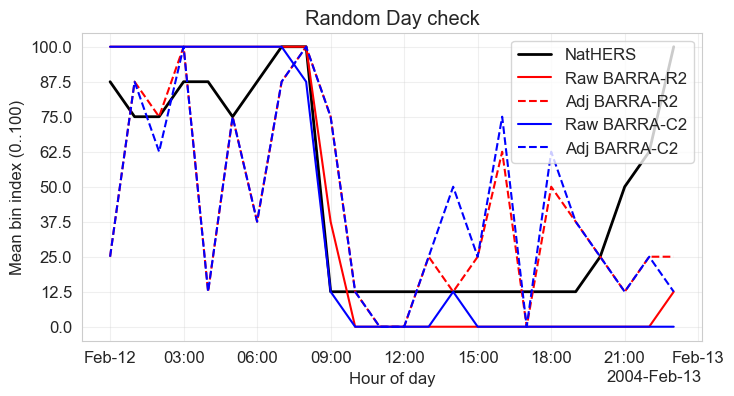

In [51]:
#— random day
day = "2004-02-12"
obs_hourly = nathers_binned.binned.sel(time=day)
mod_hourly = barra_binned.binned.sel(time=day)
adj_hourly = mod_adj_binned.binned.sel(time=day)
modc2_hourly = barrac2_binned.binned.sel(time=day)
adjc2_hourly = mod_adj_c2_binned.binned.sel(time=day)

plt.figure(figsize=(8,4))
obs_hourly.plot(label="NatHERS", lw=2, color="black")
mod_hourly.plot(label="Raw BARRA-R2", lw=1.5, color="red")
adj_hourly.plot(label="Adj BARRA-R2", lw=1.5, color="red", ls="--")
modc2_hourly.plot(label="Raw BARRA-C2", lw=1.5, color="blue")
adjc2_hourly.plot(label="Adj BARRA-C2", lw=1.5, color="blue", ls="--")

plt.xlabel("Hour of day")
plt.ylabel("Mean bin index (0..100)")
plt.yticks(bins[:-1])
plt.title("Random Day check")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Cloud cover climatology